In [105]:
library(data.table)
library(ggplot2)
library(dplyr)

In [106]:
prices = fread('room_prices.csv')[,1:5] %>%
    setnames(c('Location', 'Room', 'Type', 'Rent', 'year')) %>% 
    .[,year :=as.factor(year)]

In [107]:
prices_predicted = prices %>% copy() %>% 
    .[year=='2023'] %>% 
    .[,Rent:=Rent*1.1746] %>%
    .[,year:='2023 + 17.46%'] 

In [108]:
prices = rbind(prices, prices_predicted) %>% 
    .[,year:=factor(year, levels=(c('2023', '2023 + 17.46%', '2024')))]

In [124]:
paste('2023 statistics')
summary(prices[year=='2023']$Rent)
paste('2023 + 17.46% statistics')
summary(prices[year=='2023 + 17.46%']$Rent)
paste('2024 statistics')
summary(prices[year=='2024']$Rent)

[1] "2023 statistics"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  581.1   623.8   623.8   640.5   666.5   752.0 

[1] "2023 + 17.46% statistics"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  682.5   732.7   732.7   752.3   782.9   883.3 

[1] "2024 statistics"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  682.6   732.8   783.0   797.1   883.3   983.7 

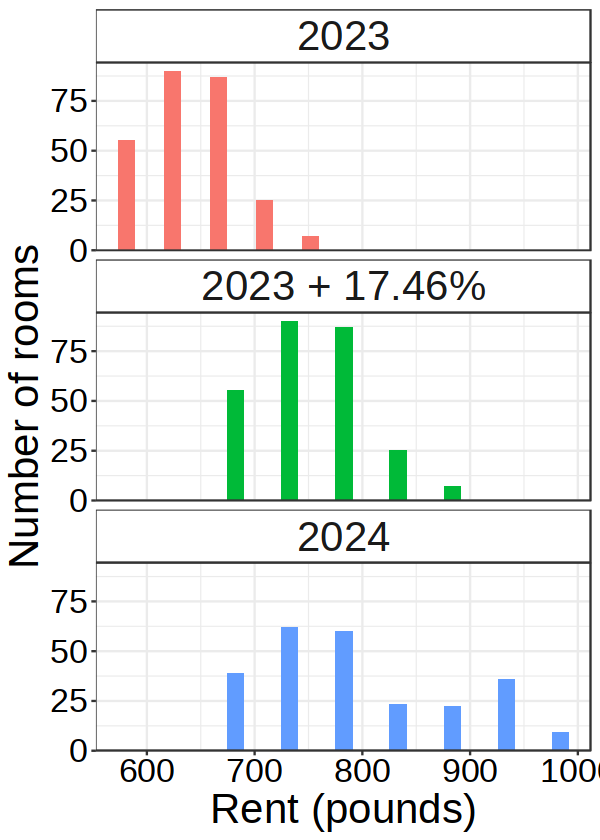

In [126]:
options(repr.plot.width=5, repr.plot.height=7)
ggplot(prices, aes(Rent, fill=year)) + 
    geom_bar(width=15, position='dodge') + 
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
    ylab('Number of rooms') + 
    xlab('Rent (pounds)') + 
    facet_wrap(~year, ncol=1) + 
    theme_bw() + 
    theme(axis.text=element_text(size=20, color='black'),
          axis.title=element_text(size=25),
          legend.position='none',
          legend.title=element_text(size=25),
          legend.text=element_text(size=20),
          strip.background=element_rect(fill='white'),
          strip.text=element_text(size=25))

In [138]:
prices.plot = prices %>%
    .[,increase := (Rent/623.8-1)*100] %>%
    .[,N:=.N, by=c('Rent', 'year')] %>% unique(by=c('Rent', 'year'))

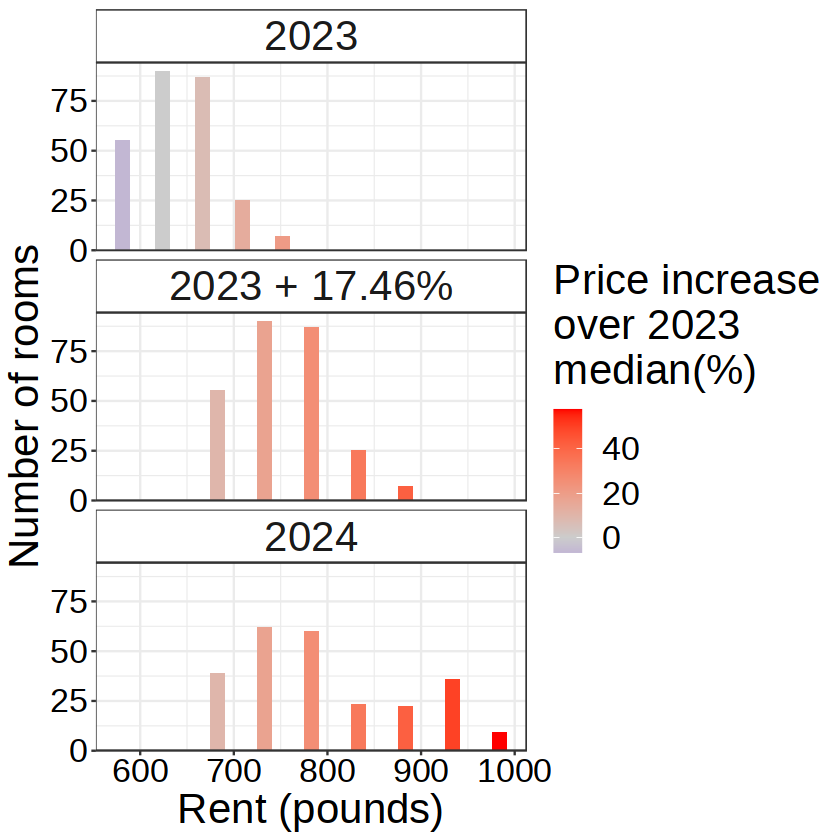

In [148]:
options(repr.plot.width=7, repr.plot.height=7)
ggplot(prices.plot, aes(Rent, N, fill=increase)) + 
    geom_bar(width=15, position='dodge', stat='identity') + 
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
    scale_fill_gradient2(low='blue', mid='grey80', high='red', name='Price increase\nover 2023\nmedian(%)') + 
    ylab('Number of rooms') + 
    xlab('Rent (pounds)') + 
    facet_wrap(~year, ncol=1) + 
    theme_bw() + 
    theme(axis.text=element_text(size=20, color='black'),
          axis.title=element_text(size=25),
          legend.position='right',
          legend.title=element_text(size=25),
          legend.text=element_text(size=20),
          strip.background=element_rect(fill='white'),
          strip.text=element_text(size=25))